# 02 — Spatial Subsetting, Cartopy and Map Projections
## จาก Latitude–Longitude Grid สู่แผนที่อุตุนิยมวิทยาที่ถูกต้องทางภูมิศาสตร์

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 EVENT teaching dataset  
**บทก่อนหน้า:** Notebook 01 — NetCDF & Xarray Fundamentals

Notebook นี้ตอบคำถามว่า:

```text
ERA5 grid อยู่ตรงไหนบนโลก?
        ↓
latitude / longitude เรียงอย่างไร?
        ↓
จะตัดเฉพาะพื้นที่ที่สนใจอย่างไร?
        ↓
Data CRS คืออะไร?
        ↓
Map projection คืออะไร?
        ↓
ทำไมต้องกำหนด transform?
        ↓
แผนที่เดียวกันจึงดูต่างกันเมื่อเปลี่ยน projection?
```

แนวคิดสำคัญ:

> **Spatial subsetting เปลี่ยนพื้นที่ที่เราใช้วิเคราะห์**

แต่:

> **Map projection เปลี่ยนวิธีแสดงตำแหน่งบนระนาบแผนที่ ไม่ได้เปลี่ยนค่าทางกายภาพของ ERA5**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบาย latitude และ longitude ใน ERA5 grid
2. ตรวจ coordinate ordering
3. ใช้ `.sel()` และ `slice()` เพื่อ spatial subset
4. อธิบายผลของ latitude ordering ต่อ `slice()`
5. แยก data coordinate system กับ display projection
6. อธิบาย `ccrs.PlateCarree()`
7. แยกหน้าที่ของ `projection=` และ `transform=`
8. สร้างแผนที่ ERA5 ด้วย Cartopy
9. เปรียบเทียบ Plate Carrée, Mercator และ Lambert Conformal
10. แสดง spatial domain และ subset boxes
11. แสดง teaching grid centers
12. อธิบายว่า 0.5° grid spacing ไม่เท่ากับ physical resolution
13. export figures และ spatial metadata

# 1. Latitude–Longitude Grid

ERA5 teaching dataset ใช้ geographic coordinates:

```text
latitude
longitude
```

latitude บอกตำแหน่งเหนือ–ใต้ ส่วน longitude บอกตำแหน่งตะวันออก–ตะวันตก

ข้อมูล teaching dataset ใช้ grid spacing ประมาณ:

```text
0.5° × 0.5°
```

# 2. Grid Spacing ไม่เท่ากับระยะทางคงที่บนโลก

หนึ่ง degree ของ latitude มีระยะทางประมาณ:

$$
1^\circ_{\mathrm{lat}}
\approx
111\ \mathrm{km}
$$

ดังนั้น 0.5° latitude มีระยะประมาณ:

$$
0.5^\circ
\approx
55.5\ \mathrm{km}
$$

แต่ longitude เปลี่ยนตาม latitude:

$$
L_{\mathrm{lon}}
\approx
111\cos(\phi)
$$

กิโลเมตรต่อหนึ่ง degree โดย $\phi$ คือ latitude

ดังนั้น grid 0.5° × 0.5° ไม่ได้มีขนาดกิโลเมตรเท่ากันทุก latitude

# 3. Spatial Subsetting

EVENT dataset ครอบคลุมประมาณ:

```text
60–130°E
5°S–45°N
```

ถ้าสนใจ Thailand–Indochina:

```text
90–110°E
5–25°N
```

เราสามารถเลือก:

```python
subset = field.sel(
    longitude=slice(90, 110),
    latitude=slice(25, 5),
)
```

เหตุผลที่ latitude เป็น `slice(25, 5)` เพราะ latitude ใน ERA5 ชุดนี้เรียงจากเหนือไปใต้

# 4. CRS กับ Map Projection

### Coordinate Reference System — CRS

บอกว่าพิกัดในข้อมูลอ้างอิงโลกอย่างไร

ERA5 ของเราใช้ longitude / latitude

### Map Projection

คือวิธีแปลงพื้นผิวโค้งของโลกลงบนระนาบ 2 มิติ

```text
Earth surface
     ↓
mathematical transformation
     ↓
2-D map
```

ทุก projection มี distortion บางชนิด เช่น area, shape, distance หรือ direction

# 5. Plate Carrée

Plate Carrée ใช้ longitude และ latitude โดยตรงบนแกนแผนที่

$$
x=\lambda
$$

$$
y=\phi
$$

จึงเหมาะสำหรับเริ่มเรียน spatial atmospheric data

# 6. Mercator Projection

Mercator รักษามุมเฉพาะที่ได้ดี แต่ขยายพื้นที่บริเวณ latitude สูง

แนวคิดโดยย่อ:

$$
x=R\lambda
$$

$$
y=
R\ln
\left[
\tan
\left(
\frac{\pi}{4}
+
\frac{\phi}{2}
\right)
\right]
$$

# 7. Lambert Conformal Conic

Lambert Conformal Conic เหมาะกับพื้นที่ mid-latitude ที่มีแนวกว้างตะวันออก–ตะวันตก และนิยมใช้กับ weather maps ในหลายภูมิภาค

หลักสำคัญ:

```text
same atmospheric data
+
different map projection
=
different visual geometry
```

แต่ค่าทางกายภาพของ ERA5 ไม่เปลี่ยน

# 8. `projection=` กับ `transform=` ต่างกันอย่างไร?

ใน Cartopy:

```python
ax = plt.axes(
    projection=ccrs.Mercator()
)
```

คือ projection ของแผนที่ output

แต่เมื่อ plot ERA5:

```python
ax.pcolormesh(
    lon,
    lat,
    field,
    transform=ccrs.PlateCarree(),
)
```

`transform=` บอก coordinate system ของ input data

ดังนั้น:

```text
projection
→ output map geometry

transform
→ input data coordinate interpretation
```

# 9. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 10. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print(
    "Google Drive mounted:",
    DRIVE_ROOT,
)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 11. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import math
import sys

from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 12. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "02"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

if not EVENT_FILE.exists():
    raise FileNotFoundError(
        "EVENT teaching dataset not found. "
        "Run Notebook 00 first."
    )

print(
    "EVENT file:",
    EVENT_FILE,
)

EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc


# 13. เปิด EVENT dataset

In [5]:
# CELL 5 — Open EVENT dataset

ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) float32 2MB ...
Attributes: (12/17)
    Conventions:              

# 14. Coordinate audit

In [6]:
# CELL 6 — Coordinate audit

latitude = ds["latitude"]
longitude = ds["longitude"]

lat_values = np.asarray(
    latitude.values,
    dtype=float,
)

lon_values = np.asarray(
    longitude.values,
    dtype=float,
)

lat_step = float(
    np.nanmedian(
        np.abs(
            np.diff(
                lat_values
            )
        )
    )
)

lon_step = float(
    np.nanmedian(
        np.abs(
            np.diff(
                lon_values
            )
        )
    )
)

COORDINATE_AUDIT = pd.DataFrame(
    [
        {
            "coordinate": "latitude",
            "minimum": float(
                np.nanmin(
                    lat_values
                )
            ),
            "maximum": float(
                np.nanmax(
                    lat_values
                )
            ),
            "step_degree": lat_step,
            "ordering": (
                "increasing"
                if lat_values[-1] > lat_values[0]
                else "decreasing"
            ),
            "n_points": int(
                latitude.size
            ),
        },
        {
            "coordinate": "longitude",
            "minimum": float(
                np.nanmin(
                    lon_values
                )
            ),
            "maximum": float(
                np.nanmax(
                    lon_values
                )
            ),
            "step_degree": lon_step,
            "ordering": (
                "increasing"
                if lon_values[-1] > lon_values[0]
                else "decreasing"
            ),
            "n_points": int(
                longitude.size
            ),
        },
    ]
)

display(
    COORDINATE_AUDIT
)

,coordinate,minimum,maximum,step_degree,ordering,n_points
0,latitude,-4.625,44.875,0.5,decreasing,100
1,longitude,60.125,129.625,0.5,increasing,140


# 15. Approximate Grid Distance

เราประมาณระยะของ grid ได้จาก:

$$
\Delta y
\approx
111.32\Delta\phi
$$

และ:

$$
\Delta x
\approx
111.32\cos(\phi)\Delta\lambda
$$

หน่วยเป็นกิโลเมตร

นี่เป็น approximation สำหรับการเรียน ไม่ใช่ geodesic distance ที่แม่นยำที่สุด

In [7]:
# CELL 7 — Approximate grid distance at selected latitudes

example_latitudes = [
    0,
    10,
    15,
    20,
    30,
]

distance_rows = []

for lat in example_latitudes:
    dy_km = (
        111.32
        * lat_step
    )

    dx_km = (
        111.32
        * math.cos(
            math.radians(
                lat
            )
        )
        * lon_step
    )

    distance_rows.append(
        {
            "latitude_deg": lat,
            "lat_grid_spacing_km_approx": dy_km,
            "lon_grid_spacing_km_approx": dx_km,
        }
    )

GRID_DISTANCE_TABLE = pd.DataFrame(
    distance_rows
)

display(
    GRID_DISTANCE_TABLE
)

,latitude_deg,lat_grid_spacing_km_approx,lon_grid_spacing_km_approx
0,0,55.66,55.660000
1,10,55.66,54.814400
2,15,55.66,53.763431
3,20,55.66,52.303291
4,30,55.66,48.202974


# 16. เลือก 850-hPa Temperature

In [8]:
# CELL 8 — Select 850-hPa temperature

field_K = (
    ds["t"]
    .sel(
        time="2011-10-02",
        level=850,
    )
)

field_C = (
    field_K
    - 273.15
)

field_C.name = (
    "temperature_C"
)

field_C.attrs = {
    "long_name": (
        "850-hPa air temperature"
    ),
    "units": "degC",
}

print(
    field_C
)

<xarray.DataArray 'temperature_C' (latitude: 100, longitude: 140)> Size: 56kB
array([[ 7.96286  ,  9.34314  , 10.705292 , ..., -6.0078125, -6.271942 ,
        -6.5718384],
       [ 8.954071 , 10.403015 , 11.679352 , ..., -5.8309326, -6.547516 ,
        -6.8469543],
       [10.130768 , 11.504395 , 12.817902 , ..., -5.7817993, -6.321045 ,
        -6.788788 ],
       ...,
       [17.012177 , 17.033142 , 17.248657 , ..., 18.186005 , 17.745453 ,
        17.373566 ],
       [17.107056 , 17.214325 , 17.01883  , ..., 17.807434 , 17.22052  ,
        17.352112 ],
       [16.912048 , 17.425049 , 16.991669 , ..., 17.702545 , 17.39978  ,
        17.375    ]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
    level      int32 4B 850
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    long_name:  850-hPa air temperature
    units:      degC


# 17. กำหนด Spatial Domains

เราจะใช้ 3 domains:

```text
FULL EVENT DOMAIN
60–130°E
5°S–45°N

REGIONAL DOMAIN
80–130°E
0–35°N

THAILAND–INDOCHINA DOMAIN
90–110°E
5–25°N
```

การเลือก domain ต้องสัมพันธ์กับคำถามที่ศึกษา

In [9]:
# CELL 9 — Domain definitions

FULL_DOMAIN = {
    "lon_min": 60.0,
    "lon_max": 130.0,
    "lat_min": -5.0,
    "lat_max": 45.0,
}

REGIONAL_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

THAI_INDOCHINA_DOMAIN = {
    "lon_min": 90.0,
    "lon_max": 110.0,
    "lat_min": 5.0,
    "lat_max": 25.0,
}

DOMAIN_TABLE = pd.DataFrame(
    [
        {
            "domain": "FULL_EVENT",
            **FULL_DOMAIN,
        },
        {
            "domain": "REGIONAL",
            **REGIONAL_DOMAIN,
        },
        {
            "domain": "THAI_INDOCHINA",
            **THAI_INDOCHINA_DOMAIN,
        },
    ]
)

display(
    DOMAIN_TABLE
)

,domain,lon_min,lon_max,lat_min,lat_max
0,FULL_EVENT,60.0,130.0,-5.0,45.0
1,REGIONAL,80.0,130.0,0.0,35.0
2,THAI_INDOCHINA,90.0,110.0,5.0,25.0


# 18. สร้าง helper สำหรับ spatial subset

In [10]:
# CELL 10 — Coordinate-aware spatial subset helper

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values.size < 2:
        return slice(
            lower,
            upper,
        )

    increasing = bool(
        values[-1]
        > values[0]
    )

    if increasing:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def spatial_subset(
    data_array,
    domain,
):
    lat_slice = coordinate_slice(
        data_array[
            "latitude"
        ],
        domain[
            "lat_min"
        ],
        domain[
            "lat_max"
        ],
    )

    lon_slice = coordinate_slice(
        data_array[
            "longitude"
        ],
        domain[
            "lon_min"
        ],
        domain[
            "lon_max"
        ],
    )

    subset = data_array.sel(
        latitude=(
            lat_slice
        ),
        longitude=(
            lon_slice
        ),
    )

    if (
        subset.sizes[
            "latitude"
        ] == 0
        or subset.sizes[
            "longitude"
        ] == 0
    ):
        raise ValueError(
            "Spatial subset is empty."
        )

    return subset

In [11]:
# CELL 11 — Create subsets

regional_C = spatial_subset(
    field_C,
    REGIONAL_DOMAIN,
)

thai_indochina_C = spatial_subset(
    field_C,
    THAI_INDOCHINA_DOMAIN,
)

SUBSET_SUMMARY = pd.DataFrame(
    [
        {
            "dataset": "FULL",
            "n_latitude": int(
                field_C.sizes[
                    "latitude"
                ]
            ),
            "n_longitude": int(
                field_C.sizes[
                    "longitude"
                ]
            ),
            "n_grid_cells": int(
                field_C.sizes[
                    "latitude"
                ]
                * field_C.sizes[
                    "longitude"
                ]
            ),
        },
        {
            "dataset": "REGIONAL",
            "n_latitude": int(
                regional_C.sizes[
                    "latitude"
                ]
            ),
            "n_longitude": int(
                regional_C.sizes[
                    "longitude"
                ]
            ),
            "n_grid_cells": int(
                regional_C.sizes[
                    "latitude"
                ]
                * regional_C.sizes[
                    "longitude"
                ]
            ),
        },
        {
            "dataset": "THAI_INDOCHINA",
            "n_latitude": int(
                thai_indochina_C.sizes[
                    "latitude"
                ]
            ),
            "n_longitude": int(
                thai_indochina_C.sizes[
                    "longitude"
                ]
            ),
            "n_grid_cells": int(
                thai_indochina_C.sizes[
                    "latitude"
                ]
                * thai_indochina_C.sizes[
                    "longitude"
                ]
            ),
        },
    ]
)

display(
    SUBSET_SUMMARY
)

,dataset,n_latitude,n_longitude,n_grid_cells
0,FULL,100,140,14000
1,REGIONAL,70,100,7000
2,THAI_INDOCHINA,40,40,1600


# 19. Figure 02-1 — Full Domain and Analysis Subsets

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


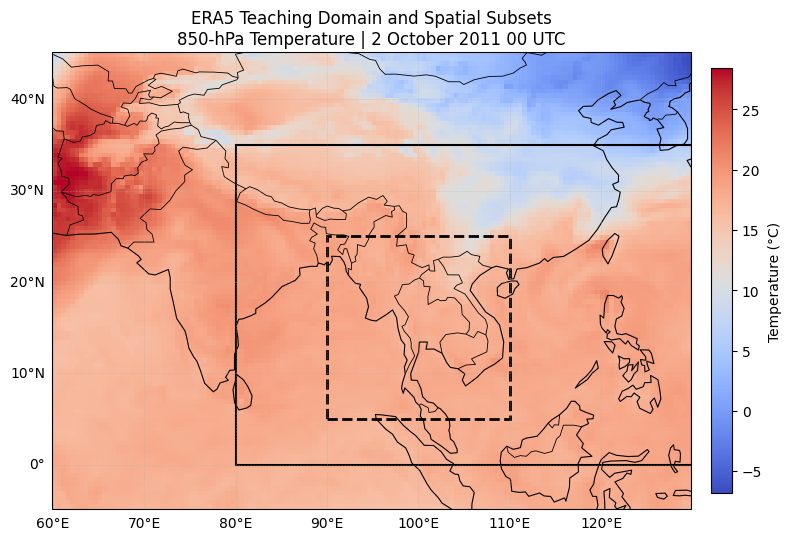

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/02/02_01_full_domain_and_spatial_subsets.png


In [12]:
# CELL 12 — Full domain map with subset boxes

fig = plt.figure(
    figsize=(
        10,
        6.5,
    )
)

ax = plt.axes(
    projection=(
        ccrs.PlateCarree()
    )
)

mesh = ax.pcolormesh(
    field_C[
        "longitude"
    ],
    field_C[
        "latitude"
    ],
    field_C,
    transform=(
        ccrs.PlateCarree()
    ),
    shading="auto",
    cmap="coolwarm",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.6,
)

regional_box = Rectangle(
    (
        REGIONAL_DOMAIN[
            "lon_min"
        ],
        REGIONAL_DOMAIN[
            "lat_min"
        ],
    ),
    (
        REGIONAL_DOMAIN[
            "lon_max"
        ]
        - REGIONAL_DOMAIN[
            "lon_min"
        ]
    ),
    (
        REGIONAL_DOMAIN[
            "lat_max"
        ]
        - REGIONAL_DOMAIN[
            "lat_min"
        ]
    ),
    fill=False,
    linewidth=1.5,
    transform=(
        ccrs.PlateCarree()
    ),
)

thai_box = Rectangle(
    (
        THAI_INDOCHINA_DOMAIN[
            "lon_min"
        ],
        THAI_INDOCHINA_DOMAIN[
            "lat_min"
        ],
    ),
    (
        THAI_INDOCHINA_DOMAIN[
            "lon_max"
        ]
        - THAI_INDOCHINA_DOMAIN[
            "lon_min"
        ]
    ),
    (
        THAI_INDOCHINA_DOMAIN[
            "lat_max"
        ]
        - THAI_INDOCHINA_DOMAIN[
            "lat_min"
        ]
    ),
    fill=False,
    linewidth=2.0,
    linestyle="--",
    transform=(
        ccrs.PlateCarree()
    ),
)

ax.add_patch(
    regional_box
)

ax.add_patch(
    thai_box
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "ERA5 Teaching Domain and Spatial Subsets\n"
    "850-hPa Temperature | 2 October 2011 00 UTC"
)

FIG_02_01 = (
    FIGURE_DIR
    / "02_01_full_domain_and_spatial_subsets.png"
)

plt.savefig(
    FIG_02_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_02_01,
)

# 20. Figure 02-2 — Thailand–Indochina Spatial Subset

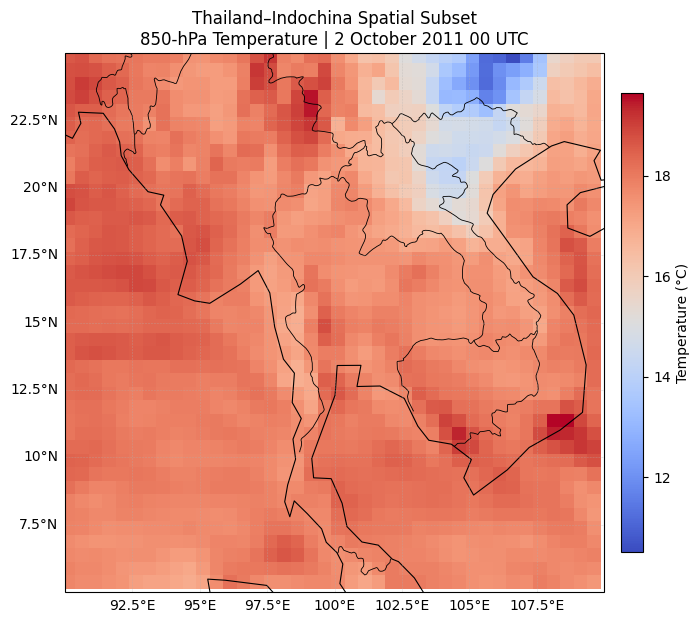

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/02/02_02_thailand_indochina_subset.png


In [13]:
# CELL 13 — Thailand–Indochina subset map

fig = plt.figure(
    figsize=(8.5, 7)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    thai_indochina_C["longitude"],
    thai_indochina_C["latitude"],
    thai_indochina_C,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.6,
)

ax.set_extent(
    [
        THAI_INDOCHINA_DOMAIN["lon_min"],
        THAI_INDOCHINA_DOMAIN["lon_max"],
        THAI_INDOCHINA_DOMAIN["lat_min"],
        THAI_INDOCHINA_DOMAIN["lat_max"],
    ],
    crs=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "Thailand–Indochina Spatial Subset\n"
    "850-hPa Temperature | 2 October 2011 00 UTC"
)

FIG_02_02 = (
    FIGURE_DIR
    / "02_02_thailand_indochina_subset.png"
)

plt.savefig(
    FIG_02_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_02_02)

# 21. เปรียบเทียบ Projection

เราจะใช้ field เดียวกันและ extent เดียวกัน แต่เปลี่ยน projection:

```text
Plate Carrée
Mercator
Lambert Conformal
```

ให้สังเกต geometry ของ coastline และ region แต่จำไว้ว่า field values ยังเป็นข้อมูลชุดเดิม

In [14]:
# CELL 14 — Projection definitions

PROJECTIONS = {
    "Plate Carrée": ccrs.PlateCarree(),
    "Mercator": ccrs.Mercator(),
    "Lambert Conformal": ccrs.LambertConformal(
        central_longitude=105.0,
        central_latitude=15.0,
        standard_parallels=(10.0, 20.0),
    ),
}

print(
    list(
        PROJECTIONS.keys()
    )
)

['Plate Carrée', 'Mercator', 'Lambert Conformal']


# 22. Figure 02-3 — Same Data, Different Map Projections

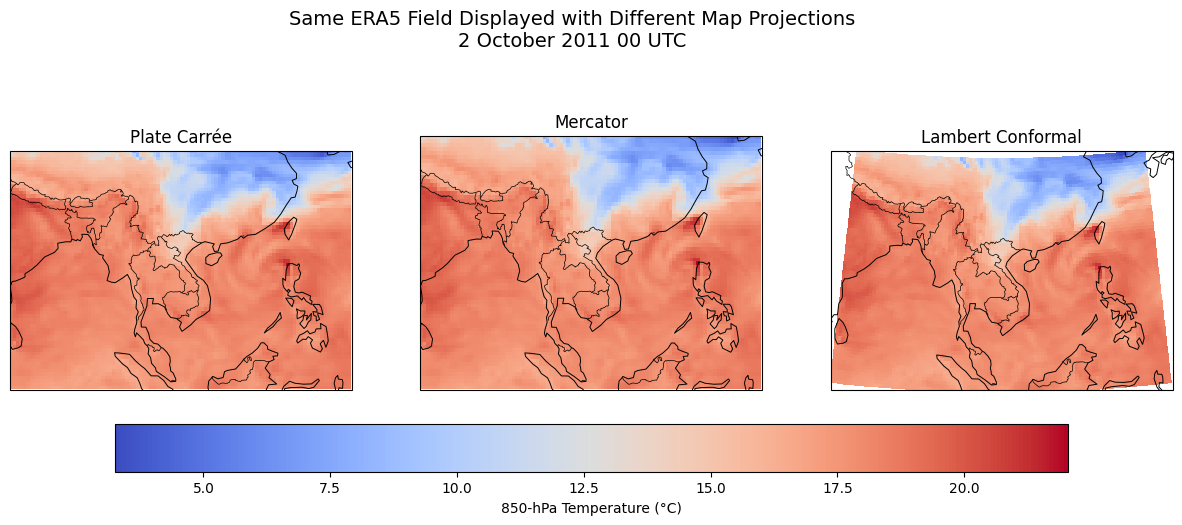

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/02/02_03_projection_comparison.png


In [15]:
# CELL 15 — Projection comparison

vmin = float(
    regional_C.min()
)

vmax = float(
    regional_C.max()
)

fig = plt.figure(
    figsize=(15, 5.5)
)

axes = []

for index, (
    projection_name,
    projection_object,
) in enumerate(
    PROJECTIONS.items(),
    start=1,
):
    ax = fig.add_subplot(
        1,
        3,
        index,
        projection=projection_object,
    )

    axes.append(ax)

    mesh = ax.pcolormesh(
        regional_C["longitude"],
        regional_C["latitude"],
        regional_C,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            REGIONAL_DOMAIN["lon_min"],
            REGIONAL_DOMAIN["lon_max"],
            REGIONAL_DOMAIN["lat_min"],
            REGIONAL_DOMAIN["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.set_title(
        projection_name
    )

cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    pad=0.08,
    shrink=0.82,
)

cbar.set_label(
    "850-hPa Temperature (°C)"
)

fig.suptitle(
    "Same ERA5 Field Displayed with Different Map Projections\n"
    "2 October 2011 00 UTC",
    fontsize=14,
)

FIG_02_03 = (
    FIGURE_DIR
    / "02_03_projection_comparison.png"
)

plt.savefig(
    FIG_02_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_02_03)

# 23. Figure 02-3 แสดงอะไร?

ภาพต่างกันเพราะ map projection ต่างกัน

แต่ไม่ได้หมายความว่า:

```text
temperature เปลี่ยน
```

หรือ:

```text
ERA5 ถูก regridded
```

input data ยังคงเป็น longitude/latitude และใช้:

```python
transform=ccrs.PlateCarree()
```

# 24. Teaching Grid Centers

In [16]:
# CELL 16 — Create a small grid-center subset

GRID_VIEW_DOMAIN = {
    "lon_min": 98.0,
    "lon_max": 104.0,
    "lat_min": 12.0,
    "lat_max": 19.0,
}

grid_view_C = spatial_subset(
    field_C,
    GRID_VIEW_DOMAIN,
)

lon_mesh, lat_mesh = np.meshgrid(
    grid_view_C["longitude"].values,
    grid_view_C["latitude"].values,
)

print(
    "Grid-view shape:",
    grid_view_C.shape,
)

Grid-view shape: (14, 12)


# 25. Figure 02-4 — ERA5 Teaching Grid Centers over Thailand

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


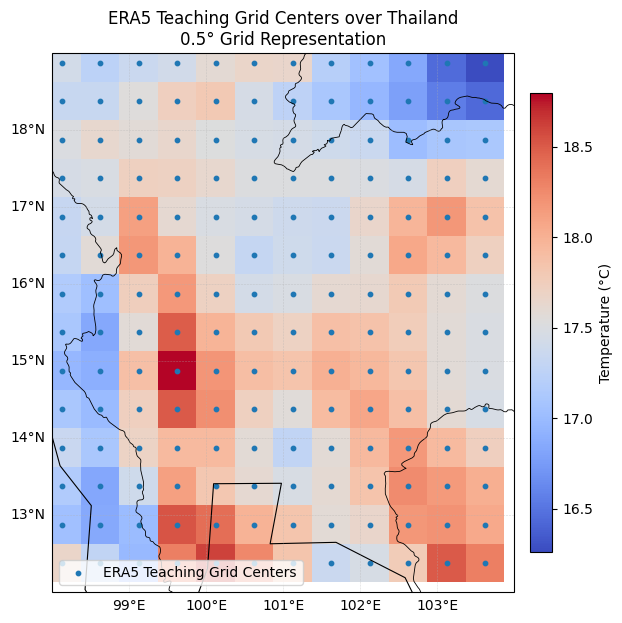

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/02/02_04_teaching_grid_centers_thailand.png


In [17]:
# CELL 17 — Grid-center map

fig = plt.figure(
    figsize=(8, 7)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    grid_view_C["longitude"],
    grid_view_C["latitude"],
    grid_view_C,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

ax.scatter(
    lon_mesh.ravel(),
    lat_mesh.ravel(),
    s=10,
    transform=ccrs.PlateCarree(),
    label="ERA5 Teaching Grid Centers",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.8,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.6,
)

ax.set_extent(
    [
        GRID_VIEW_DOMAIN["lon_min"],
        GRID_VIEW_DOMAIN["lon_max"],
        GRID_VIEW_DOMAIN["lat_min"],
        GRID_VIEW_DOMAIN["lat_max"],
    ],
    crs=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.legend(
    loc="lower left",
)

ax.set_title(
    "ERA5 Teaching Grid Centers over Thailand\n"
    "0.5° Grid Representation"
)

FIG_02_04 = (
    FIGURE_DIR
    / "02_04_teaching_grid_centers_thailand.png"
)

plt.savefig(
    FIG_02_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", FIG_02_04)

# 26. Grid Center ไม่ใช่ Pixel Observation Footprint

จุดใน Figure 02-4 คือ coordinate center ของ teaching grid

ไม่ควรตีความว่า:

```text
แต่ละจุด = weather station
```

และไม่ควรตีความว่า:

```text
0.5° grid = observational footprint จริงขนาดคงที่
```

เพราะ teaching dataset ถูก coarsen จาก source grid และ ERA5 เป็น reanalysis

# 27. Experiment — ทำไม `transform` สำคัญ?

เมื่อส่ง longitude/latitude เข้า Cartopy ต้องระบุว่า coordinate input เป็นอะไร

สำหรับ ERA5:

```python
transform=ccrs.PlateCarree()
```

ถึงแม้ axes จะใช้ Mercator หรือ Lambert Conformal

เพราะ:

```text
projection
≠
transform
```

# 28. Data Subsetting ≠ Projection

สรุป:

```text
Spatial subsetting
→ เลือก grid cells ที่จะใช้

Projection
→ เปลี่ยนวิธีแสดง grid cells บนแผนที่

Regridding
→ เปลี่ยน grid ที่ใช้แทนข้อมูล

Coarsening
→ รวมหลาย grid cells เพื่อสร้าง representation ที่หยาบขึ้น
```

สี่กระบวนการนี้ไม่ควรถูกใช้แทนกัน

# 29. Export Spatial Metadata

In [18]:
# CELL 18 — Export spatial metadata

SPATIAL_METADATA = pd.DataFrame(
    [
        {
            "parameter": "latitude_order",
            "value": (
                "increasing"
                if lat_values[-1] > lat_values[0]
                else "decreasing"
            ),
        },
        {
            "parameter": "longitude_order",
            "value": (
                "increasing"
                if lon_values[-1] > lon_values[0]
                else "decreasing"
            ),
        },
        {
            "parameter": "latitude_step_degree",
            "value": lat_step,
        },
        {
            "parameter": "longitude_step_degree",
            "value": lon_step,
        },
        {
            "parameter": "data_coordinate_interpretation",
            "value": (
                "Geographic longitude-latitude"
            ),
        },
        {
            "parameter": "cartopy_input_transform",
            "value": "PlateCarree",
        },
        {
            "parameter": "source_grid_spacing_degree",
            "value": ds.attrs.get(
                "source_horizontal_grid_spacing_deg",
                "",
            ),
        },
        {
            "parameter": "teaching_grid_spacing_degree",
            "value": ds.attrs.get(
                "teaching_horizontal_grid_spacing_deg",
                "",
            ),
        },
    ]
)

SPATIAL_METADATA_CSV = (
    METADATA_DIR
    / "02_spatial_coordinate_and_projection_metadata.csv"
)

SPATIAL_METADATA.to_csv(
    SPATIAL_METADATA_CSV,
    index=False,
)

display(
    SPATIAL_METADATA
)

print(
    "Saved:",
    SPATIAL_METADATA_CSV,
)

,parameter,value
0,latitude_order,decreasing
1,longitude_order,increasing
2,latitude_step_degree,0.5
3,longitude_step_degree,0.5
4,data_coordinate_interpretation,Geographic longitude-latitude
5,cartopy_input_transform,PlateCarree
6,source_grid_spacing_degree,0.25
7,teaching_grid_spacing_degree,0.5


Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/02_spatial_coordinate_and_projection_metadata.csv


# 30. Export Subset Summary

In [19]:
# CELL 19 — Export subset summary

SUBSET_SUMMARY_CSV = (
    OUTPUT_DIR
    / "02_spatial_subset_summary.csv"
)

SUBSET_SUMMARY.to_csv(
    SUBSET_SUMMARY_CSV,
    index=False,
)

DOMAIN_TABLE_CSV = (
    OUTPUT_DIR
    / "02_analysis_domains.csv"
)

DOMAIN_TABLE.to_csv(
    DOMAIN_TABLE_CSV,
    index=False,
)

GRID_DISTANCE_CSV = (
    OUTPUT_DIR
    / "02_grid_spacing_distance_approximation.csv"
)

GRID_DISTANCE_TABLE.to_csv(
    GRID_DISTANCE_CSV,
    index=False,
)

print(
    "Saved:",
    SUBSET_SUMMARY_CSV,
)

print(
    "Saved:",
    DOMAIN_TABLE_CSV,
)

print(
    "Saved:",
    GRID_DISTANCE_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/02_spatial_subset_summary.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/02_analysis_domains.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/02_grid_spacing_distance_approximation.csv


# 31. Figure Manifest

In [20]:
# CELL 20 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "02-01",
            "file": str(
                FIG_02_01
            ),
            "description": (
                "Full teaching domain with regional subset boxes"
            ),
        },
        {
            "figure": "02-02",
            "file": str(
                FIG_02_02
            ),
            "description": (
                "Thailand–Indochina 850-hPa temperature subset"
            ),
        },
        {
            "figure": "02-03",
            "file": str(
                FIG_02_03
            ),
            "description": (
                "Same ERA5 field in Plate Carree, Mercator, "
                "and Lambert Conformal projections"
            ),
        },
        {
            "figure": "02-04",
            "file": str(
                FIG_02_04
            ),
            "description": (
                "ERA5 teaching grid centers over Thailand"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "02_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,02-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Full teaching domain with regional subset boxes
1,02-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Thailand–Indochina 850-hPa temperature subset
2,02-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"Same ERA5 field in Plate Carree, Mercator, and..."
3,02-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,ERA5 teaching grid centers over Thailand


# 32. Common Mistakes

### Mistake 1
ใช้:

```python
latitude=slice(5,25)
```

ทั้งที่ latitude coordinate เรียงจากเหนือไปใต้

### Mistake 2
คิดว่าเปลี่ยน projection แล้วค่าข้อมูลเปลี่ยน

### Mistake 3
ลืม `transform=ccrs.PlateCarree()` ตอน plot longitude/latitude data

### Mistake 4
คิดว่า 0.5° grid spacing เท่ากับ 55 km ทั้งสองแกนทุก latitude

### Mistake 5
เรียก spatial subsetting ว่า regridding

### Mistake 6
ตีความ grid center ว่าเป็น weather station

# 33. Exercises

### Exercise 1 — New Domain
สร้าง subset:

```text
95–107°E
10–22°N
```

แล้วรายงานจำนวน grid cells

### Exercise 2 — Coordinate Ordering
ตรวจว่า latitude และ longitude เป็น increasing หรือ decreasing

### Exercise 3 — Projection Comparison
ใช้ field เดียวกันเปรียบเทียบ Plate Carrée, Mercator และ Lambert Conformal

### Exercise 4 — Grid Distance
คำนวณ approximate east–west spacing ของ 0.5° grid ที่ 5°N, 15°N, 25°N และ 35°N

### Exercise 5 — Interpretation
อธิบายด้วยคำของตนเอง:

```text
Data CRS
≠
Map Projection
≠
Spatial Subset
≠
Regridding
```

# 34. Final Readiness Check

In [21]:
# CELL 21 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


add_check(
    "EVENT dataset opened",
    isinstance(
        ds,
        xr.Dataset,
    ),
)

add_check(
    "Latitude ordering identified",
    "ordering" in COORDINATE_AUDIT.columns,
)

add_check(
    "Thailand–Indochina subset non-empty",
    (
        thai_indochina_C.sizes["latitude"] > 0
        and thai_indochina_C.sizes["longitude"] > 0
    ),
)

add_check(
    "Full-domain subset figure exported",
    FIG_02_01.exists(),
)

add_check(
    "Thailand–Indochina figure exported",
    FIG_02_02.exists(),
)

add_check(
    "Projection comparison exported",
    FIG_02_03.exists(),
)

add_check(
    "Grid-center figure exported",
    FIG_02_04.exists(),
)

add_check(
    "Spatial metadata exported",
    SPATIAL_METADATA_CSV.exists(),
)

add_check(
    "Subset summary exported",
    SUBSET_SUMMARY_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS["status"]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "02_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 02 READY"
    )
    print(
        "Next: Notebook 03 — Pressure-Level Atmospheric Structure"
    )
else:
    print(
        "NOTEBOOK 02 REQUIRES REVIEW"
    )

,item,status,note
0,EVENT dataset opened,PASS,
1,Latitude ordering identified,PASS,
2,Thailand–Indochina subset non-empty,PASS,
3,Full-domain subset figure exported,PASS,
4,Thailand–Indochina figure exported,PASS,
5,Projection comparison exported,PASS,
6,Grid-center figure exported,PASS,
7,Spatial metadata exported,PASS,
8,Subset summary exported,PASS,



NOTEBOOK 02 READY
Next: Notebook 03 — Pressure-Level Atmospheric Structure


# 35. สิ่งที่ต้องจำจาก Notebook 02

```text
Latitude / longitude
→ data coordinates

Spatial subset
→ choose part of the grid

projection
→ map display geometry

transform
→ coordinate system of input data

grid spacing
≠ physical resolution

0.5° latitude distance
≠ 0.5° longitude distance everywhere

same ERA5 field
+
different projection
=
same data, different visual representation
```

> **การทำแผนที่ที่ถูกต้องเริ่มจากการรู้ว่าข้อมูลของเรามีพิกัดอะไร และกำลังแสดงผลด้วย projection อะไร**

# Course Progress

```text
00  Download & Data Audit        ✓
 ↓
01  NetCDF & Xarray Fundamentals ✓
 ↓
02  Spatial Subsetting & Cartopy ✓
 ↓
03  Pressure-Level Atmospheric Structure
 ↓
04  Wind & Vector Analysis
 ↓
05  Synoptic Weather Maps & Dynamics
 ↓
06  Hovmöller & Spatiotemporal Analysis
 ↓
07  Climatology
 ↓
08  Anomaly
 ↓
09  Integrated Noul 2011 Case Study
```